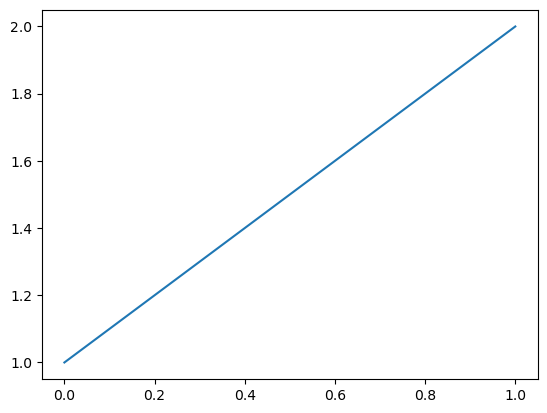

In [2]:
import matplotlib.pyplot as plt

plt.plot([0, 1], [1, 2])

In [3]:
import torch
import numpy as np

In [18]:
from torch import nn
from torch.func import vmap, jacrev, jacfwd

class MLPGMMUnbias(nn.Module):
    def __init__(self, dim, hidden, hutch=1, eps=0):
        super().__init__()
        hidden = [dim + 1] + hidden + [2 * dim]

        layers = []
        for i in range(len(hidden) - 2):
            layers.append(nn.Linear(hidden[i], hidden[i + 1], bias=True))
            layers.append(nn.GELU())
        layers.append(nn.Linear(hidden[-2], hidden[-1], bias=True))

        self.layers = nn.Sequential(*nn.ModuleList(layers))
        self.dim = dim
        self.eps = eps
        self.hutch = hutch
        self.mod = 1.0

    def forward(self, T, state, reverse=False, div = "hutch", eps = 0):
        def single_drift(x, t):
            inp = torch.cat([x, t.unsqueeze(0)])
            return self.layers(inp).reshape(2, self.dim)
        
        with torch.set_grad_enabled(True):
            if div == "hutch":
                state[0].requires_grad_(True)
            jvp_x = vmap(single_drift, in_dims=(0, 0), out_dims=(0), 
                            randomness='different')(state[0], T.repeat(len(state[0])))
                
            if div == "None":
                if reverse == True:
                    return self.mod * jvp_x[:,0] + self.eps * jvp_x[:,1]
                else:
                    return self.mod * jvp_x[:,0] - self.eps * jvp_x[:,1]
            elif div == "exact":
                dlogJ = vmap(jacfwd(single_drift, argnums=0), out_dims=(0), 
                             randomness='different')(state[0], T.repeat(len(state[0]))).squeeze()
                dlogJ = torch.einsum('ijkk -> ji', dlogJ)
                if reverse == True:
                    return jvp_x[:,0], -dlogJ[0]
                else:
                    return jvp_x[:,0], -dlogJ[0]
            elif div == "hutch":
                epsilon = torch.randn((self.hutch, ) + state[0].shape)
                jvp = torch.autograd.grad(jvp_x[:, 0], state[0], epsilon, allow_unused=True,create_graph=True,is_grads_batched=True)[0]
                dlogJ = torch.einsum('ba...,ba...->a', jvp, epsilon) / self.hutch
                if reverse == True:
                    return jvp_x[:,0], -dlogJ
                else:
                    return jvp_x[:,0], -dlogJ

In [133]:
class Exact(nn.Module):
    def __init__(self, dim, hidden, hutch=1, eps=0):
        super().__init__()
        hidden = [dim + 1] + hidden + [2 * dim]

        layers = []
        for i in range(len(hidden) - 2):
            layers.append(nn.Linear(hidden[i], hidden[i + 1], bias=True))
            layers.append(nn.GELU())
        layers.append(nn.Linear(hidden[-2], hidden[-1], bias=True))

        self.layers = nn.Sequential(*nn.ModuleList(layers))
        self.dim = dim
        self.eps = eps
        self.hutch = hutch
        self.mod = 1.0

    def forward(self, T, state, reverse=False, div = "hutch", eps = 0):
        if reverse != True:
            return self.mod*0.4*state[0]/(0.5-0.4*T) - 2*self.eps*(0.5-0.4*T)*state[0]
        else:
            return self.mod*0.4*state[0]/(0.5-0.4*T) + 2*self.eps*(0.5-0.4*T)*state[0]

In [19]:
class SimpleNormal:
    def __init__(self, loc, var):
        self.dist = torch.distributions.normal.Normal(
            torch.flatten(loc), torch.flatten(var))
        self.shape = loc.shape
    def log_prob(self, x):
        logp = self.dist.log_prob(x.reshape(x.shape[0], -1))
        return torch.sum(logp, dim=1)
    def sample_n(self, batch_size):
        x = self.dist.sample((batch_size, ))
        return x.reshape(batch_size, *self.shape)

In [20]:
model = MLPGMMUnbias(1, [16], eps = 0.1)
prior = SimpleNormal(torch.zeros((1, )), torch.ones((1, )))
target = SimpleNormal(torch.zeros((1, )), torch.ones((1, )) * 5)

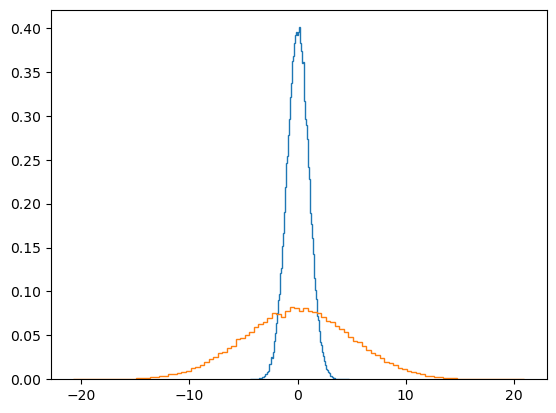

In [21]:
x = prior.sample_n(100000)
y = target.sample_n(100000)
plt.hist(x.mean(-1), bins = 100, histtype='step', density=True)
plt.hist(y.mean(-1), bins = 100, histtype='step', density=True)
plt.show()

In [25]:
def sdeint(model, x, logq, eps, times, noises):
    for noise, t0, t1 in zip(noises[:-1], times[:-1], times[1:]):
        dt = t1 - t0
        drift = model.forward(t0, (x, logq), reverse=False, div="None")
        P = noise * torch.sqrt(2 * eps * torch.abs(dt))
        x = x + drift * dt + P
        M = (model.forward(t0, (x, logq), reverse=True, div="None") - drift) * dt - P
        Rp = torch.einsum('i..., i... -> i', P, P) / (4 * eps * torch.abs(dt))
        Rm = torch.einsum('i..., i... -> i', M, M) / (4 * eps * torch.abs(dt))
        logq = logq - Rp + Rm
    return x, logq

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [44]:
for i in range(1000):
    optimizer.zero_grad()

    x = prior.sample_n(2000)
    logq = prior.log_prob(x)
    times = torch.arange(0.0, 1.0, 0.01)
    noises = torch.randn((len(times), *x.shape))
    model.eps = 0.005
    x, logq = sdeint(model, x, logq, 0.005, times, noises)
    logp = target.log_prob(x)
    loss = (logq - logp).mean()
    loss.backward()

    optimizer.step()

    print(i, loss)

0 tensor(0.0494, grad_fn=<MeanBackward0>)
1 tensor(0.0505, grad_fn=<MeanBackward0>)
2 tensor(0.0459, grad_fn=<MeanBackward0>)
3 tensor(0.0472, grad_fn=<MeanBackward0>)
4 tensor(0.0350, grad_fn=<MeanBackward0>)
5 tensor(0.0416, grad_fn=<MeanBackward0>)
6 tensor(0.0509, grad_fn=<MeanBackward0>)
7 tensor(0.0411, grad_fn=<MeanBackward0>)
8 tensor(0.0270, grad_fn=<MeanBackward0>)
9 tensor(0.0524, grad_fn=<MeanBackward0>)
10 tensor(0.0375, grad_fn=<MeanBackward0>)
11 tensor(0.0276, grad_fn=<MeanBackward0>)
12 tensor(0.0398, grad_fn=<MeanBackward0>)
13 tensor(0.0434, grad_fn=<MeanBackward0>)
14 tensor(0.0388, grad_fn=<MeanBackward0>)
15 tensor(0.0458, grad_fn=<MeanBackward0>)
16 tensor(0.0444, grad_fn=<MeanBackward0>)
17 tensor(0.0472, grad_fn=<MeanBackward0>)
18 tensor(0.0383, grad_fn=<MeanBackward0>)
19 tensor(0.0478, grad_fn=<MeanBackward0>)
20 tensor(0.0547, grad_fn=<MeanBackward0>)
21 tensor(0.0525, grad_fn=<MeanBackward0>)
22 tensor(0.0414, grad_fn=<MeanBackward0>)
23 tensor(0.0538, gra

KeyboardInterrupt: 

In [140]:
ledom = Exact(1, [16], eps=0.005)

with torch.no_grad():
    x = prior.sample_n(20000)
    logq = prior.log_prob(x)
    times = torch.arange(0.0, 1.0, 0.01)
    noises = torch.randn((len(times), *x.shape))
    # model.eps = 0.005
    # model.mod = 0.0
    # y, logq = sdeint(model, x, logq, 0.005, times, noises)
    ledom.eps = 100.1
    ledom.mod = 0.0
    y, logq = sdeint(ledom, x, logq, 100.1, times, noises)
    z = target.sample_n(20000)

In [141]:
print(logq.mean())

tensor(-2.1105)


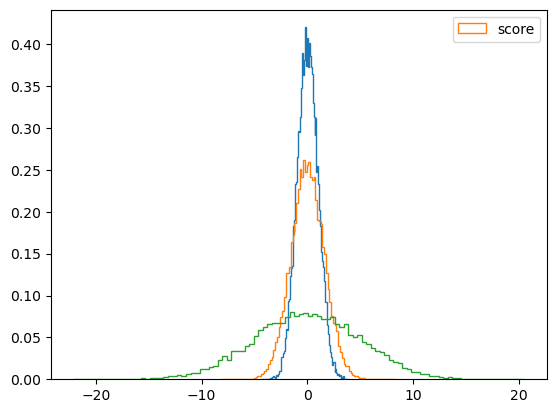

In [142]:
plt.hist(x.mean(-1), bins = 100, histtype='step', density=True)
plt.hist(y.mean(-1), bins = 100, histtype='step', density=True, weights=torch.exp(logq-torch.logsumexp(logq, 0)), label='score')
plt.hist(z.mean(-1), bins = 100, histtype='step', density=True)
plt.legend()
plt.show()

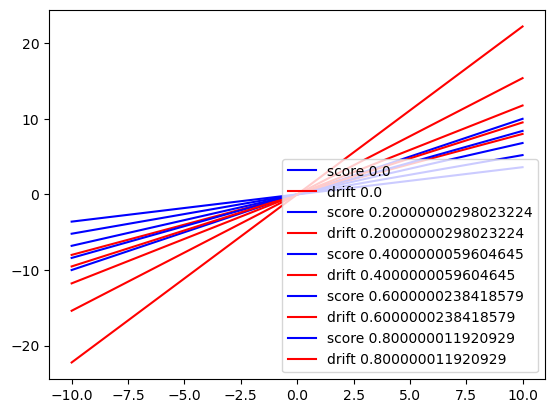

In [100]:
for t in torch.arange(0, 1.0, 0.2):
    with torch.no_grad():
        x = torch.arange(-10, 10, 0.01).unsqueeze(-1)
        # model.mod = 0.0
        # model.eps = 1.0
        # y = model.forward(t, (x, 0), div='None')
        # model.mod = 1.0
        # model.eps = 0.0
        # z = model.forward(t, (x, 0), div='None')
        ledom.mod = 0.0
        ledom.eps = 1.0
        y = ledom.forward(t, (x, 0), div='None')
        ledom.mod = 1.0
        ledom.eps = 0.0
        z = ledom.forward(t, (x, 0), div='None')
        
    plt.plot(x.detach().numpy(), y.detach().numpy(), label=f'score {t}', color='blue')
    plt.plot(x.detach().numpy(), z.detach().numpy(), label=f'drift {t}', color='red')
plt.legend()
plt.show()

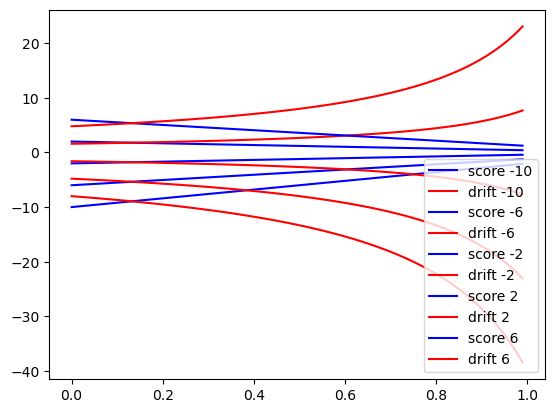

In [99]:
x = torch.arange(-10, 10, 4)
with torch.no_grad():
    times = torch.arange(0, 1.0, 0.01)
    y, z = [], []
    # model.mod = 0.0
    # model.eps = 1.0
    # for t in times:
    #     y.append(model.forward(t, (x.unsqueeze(-1), 0), div='None').detach().numpy())
    # model.mod = 1.0
    # model.eps = 0.0
    # for t in times:
    #     z.append(model.forward(t, (x.unsqueeze(-1), 0), div='None').detach().numpy())
    
    ledom.mod = 0.0
    ledom.eps = 1.0
    for t in times:
        y.append(ledom.forward(t, (x.unsqueeze(-1), 0), div='None').detach().numpy())
    ledom.mod = 1.0
    ledom.eps = 0.0
    for t in times:
        z.append(ledom.forward(t, (x.unsqueeze(-1), 0), div='None').detach().numpy())

    y = np.array(y)
    z = np.array(z)    
    for i in range(len(y[0])):
        plt.plot(times.detach().numpy(), y[:, i], label=f'score {x[i]}', color='blue')
        plt.plot(times.detach().numpy(), z[:, i], label=f'drift {x[i]}', color='red')
plt.legend()
plt.show()